# 🏙️ Eksploracyjna Analiza Danych: Rynek Nieruchomości w Warszawie (grudzień 2023)

> **Projekt zaliczeniowy** | Analiza Danych – studia podyplomowe  
> **Źródło danych:** [apartments_pl_2023_12.csv](https://raw.githubusercontent.com/kflisikowsky/analiza_danych_projekt_zespolowy/refs/heads/main/Nieruchomosci%20w%20Polsce/apartments_pl_2023_12.csv)  
> **Zakres:** miasto Warszawa, grudzień 2023

---

## 1. Wprowadzenie

### 1.1 Opis zbioru danych

Analizowany zbiór danych pochodzi z polskiego rynku nieruchomości i zawiera ogłoszenia sprzedaży mieszkań z **15 miast Polski** w grudniu 2023 roku. Dane zostały zebrane ze stron ogłoszeniowych i obejmują zarówno cechy fizyczne lokali (powierzchnia, liczba pokoi, piętro, rok budowy), jak i atrybuty lokalizacyjne (odległość od centrum, szkół, przychodni, restauracji itd.) oraz właściwości infrastrukturalne budynku (materiał, stan techniczny, winda, parking).

Na potrzeby niniejszej analizy ograniczamy się wyłącznie do **Warszawy**, będącej największym i najdroższym rynkiem nieruchomości w Polsce.

### 1.2 Charakterystyka zbioru (Warszawa)

| Parametr | Wartość |
|---|---|
| Liczba obserwacji | **4 931** |
| Liczba zmiennych | **28** |
| Zakres cenowy | 475 000 – 3 250 000 PLN |
| Średnia cena | ~1 046 000 PLN |
| Średnia cena za m² | ~17 183 PLN/m² |

### 1.3 Opis zmiennych

| Zmienna | Typ | Opis |
|---|---|---|
| `id` | str | Unikalny identyfikator ogłoszenia |
| `city` | str | Miasto |
| `type` | str | Typ budynku (blok, kamienica, apartamentowiec) |
| `squareMeters` | float | Powierzchnia mieszkania [m²] |
| `rooms` | float | Liczba pokoi |
| `floor` | float | Piętro |
| `floorCount` | float | Liczba pięter w budynku |
| `buildYear` | float | Rok budowy |
| `latitude` / `longitude` | float | Współrzędne geograficzne |
| `centreDistance` | float | Odległość od centrum [km] |
| `poiCount` | float | Liczba POI (punktów zainteresowania) w okolicy |
| `schoolDistance`, `clinicDistance`, … | float | Odległości od usług [km] |
| `ownership` | str | Forma własności (condominium / cooperative) |
| `buildingMaterial` | str | Materiał budynku (cegła, płyta, …) |
| `condition` | str | Stan techniczny (premium / low) |
| `hasParkingSpace`, `hasBalcony`, … | str | Cechy binarne (yes/no) |
| `price` | int | Cena ofertowa [PLN] |

### 1.4 Pytania badawcze

1. **Jakie są typowe parametry** warszawskiego mieszkania na sprzedaż (rozkłady powierzchni, cen, liczby pokoi)?  
2. **Co wpływa na cenę?** Czy lokalizacja (odległość od centrum), rok budowy, materiał budynku i udogodnienia są istotnie powiązane z ceną?  
3. **Jaka jest jakość danych?** Gdzie i w jakim wzorcu występują braki, błędy i obserwacje odstające?  
4. **Jakie segmenty rynku** można wyróżnić na podstawie analizowanych cech?


## 2. Czyszczenie i porządkowanie danych
### 2.0 Importy i ładowanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wizualizacji
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)
WARSZAWA_COLOR = '#E63946'

# ── Ładowanie ──────────────────────────────────────────────
URL = ('https://raw.githubusercontent.com/kflisikowsky/analiza_danych_projekt_zespolowy'
       '/refs/heads/main/Nieruchomosci%20w%20Polsce/apartments_pl_2023_12.csv')

df_all = pd.read_csv(URL)
print(f"Cały zbiór: {df_all.shape[0]:,} wierszy × {df_all.shape[1]} kolumn")
print(f"Dostępne miasta: {sorted(df_all['city'].unique())}")

df = df_all[df_all['city'] == 'warszawa'].copy().reset_index(drop=True)
print(f"\nWarszawa: {df.shape[0]:,} wierszy × {df.shape[1]} kolumn")
df.head(3)


Cały zbiór: 16,483 wierszy × 28 kolumn
Dostępne miasta: ['bialystok', 'bydgoszcz', 'czestochowa', 'gdansk', 'gdynia', 'katowice', 'krakow', 'lodz', 'lublin', 'poznan', 'radom', 'rzeszow', 'szczecin', 'warszawa', 'wroclaw']

Warszawa: 4,931 wierszy × 28 kolumn


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,5b210ac8eb98c68ab6a00e4d7015d9ce,warszawa,blockOfFlats,58.3,2.0,3.0,3.0,1989.0,52.227989,21.088249,...,0.302,condominium,NaN,NaN,no,yes,no,no,yes,770000
1,13f5f722ddb15cb723d29ca9dc90a9ec,warszawa,apartmentBuilding,135.0,5.0,1.0,5.0,2005.0,52.201025,21.027389,...,0.231,condominium,brick,low,yes,yes,yes,no,yes,3000000
2,fc696b2f9e230ccb6bd39a6669d1c61b,warszawa,blockOfFlats,25.0,1.0,1.0,3.0,1967.0,52.259889,20.965924,...,0.235,cooperative,NaN,low,no,no,no,no,yes,499000


### 2.1 Podstawowa diagnostyka

In [2]:
# Typy, liczba unikalnych wartości, % braków
diag = pd.DataFrame({
    'dtype':        df.dtypes,
    'non_null':     df.notna().sum(),
    'null_count':   df.isna().sum(),
    'null_pct':     (df.isna().mean() * 100).round(2),
    'unique':       df.nunique()
})
diag = diag.sort_values('null_pct', ascending=False)
print(diag.to_string())


                        dtype  non_null  null_count  null_pct  unique
condition                 str      1132        3799     77.04       2
buildingMaterial          str      2923        2008     40.72       2
type                      str      3652        1279     25.94       3
floor                 float64      4153         778     15.78      21
buildYear             float64      4423         508     10.30     121
hasElevator               str      4727         204      4.14       2
collegeDistance       float64      4817         114      2.31    2299
floorCount            float64      4880          51      1.03      28
clinicDistance        float64      4911          20      0.41    1645
restaurantDistance    float64      4913          18      0.37     707
pharmacyDistance      float64      4922           9      0.18     834
postOfficeDistance    float64      4927           4      0.08    1103
kindergartenDistance  float64      4927           4      0.08     683
schoolDistance      

In [3]:
# Duplikaty
n_dup = df['id'].duplicated().sum()
print(f"Zduplikowane ID: {n_dup}")
print(f"Zduplikowane wiersze (wszystkie kolumny): {df.duplicated().sum()}")


Zduplikowane ID: 0
Zduplikowane wiersze (wszystkie kolumny): 0


In [4]:
# Statystyki opisowe zmiennych numerycznych
df.describe().round(2)


,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,4931.00,4931.00,4153.00,4880.00,4423.00,4931.00,4931.00,4931.00,4931.00,4930.00,4911.00,4927.00,4927.00,4913.00,4817.00,4922.00,4931.00
mean,61.48,2.75,3.75,6.11,1988.99,52.23,21.01,5.97,22.55,0.36,0.82,0.48,0.27,0.25,1.54,0.30,1045563.80
std,23.47,0.94,2.86,3.65,28.93,0.05,0.06,3.23,22.04,0.27,0.84,0.32,0.21,0.22,1.14,0.27,470108.87
min,25.00,1.00,1.00,1.00,1851.00,52.10,20.86,0.02,0.00,0.01,0.01,0.00,0.00,0.00,0.01,0.00,475000.00
25%,45.58,2.00,2.00,4.00,1969.00,52.19,20.96,3.58,9.00,0.18,0.27,0.26,0.14,0.10,0.63,0.14,729000.00
50%,56.21,3.00,3.00,5.00,1999.00,52.23,21.01,5.71,16.00,0.29,0.54,0.42,0.24,0.19,1.17,0.23,899000.00
75%,72.19,3.00,5.00,8.00,2014.00,52.25,21.05,8.03,28.00,0.44,0.95,0.63,0.36,0.32,2.17,0.39,1230000.00
max,150.00,6.00,29.00,29.00,2023.00,52.36,21.25,16.51,136.00,2.30,4.76,3.43,2.27,1.47,5.00,2.26,3250000.00


### 2.2 Analiza braków danych
#### 2.2.1 Wizualizacja – shadowmap i heatmap

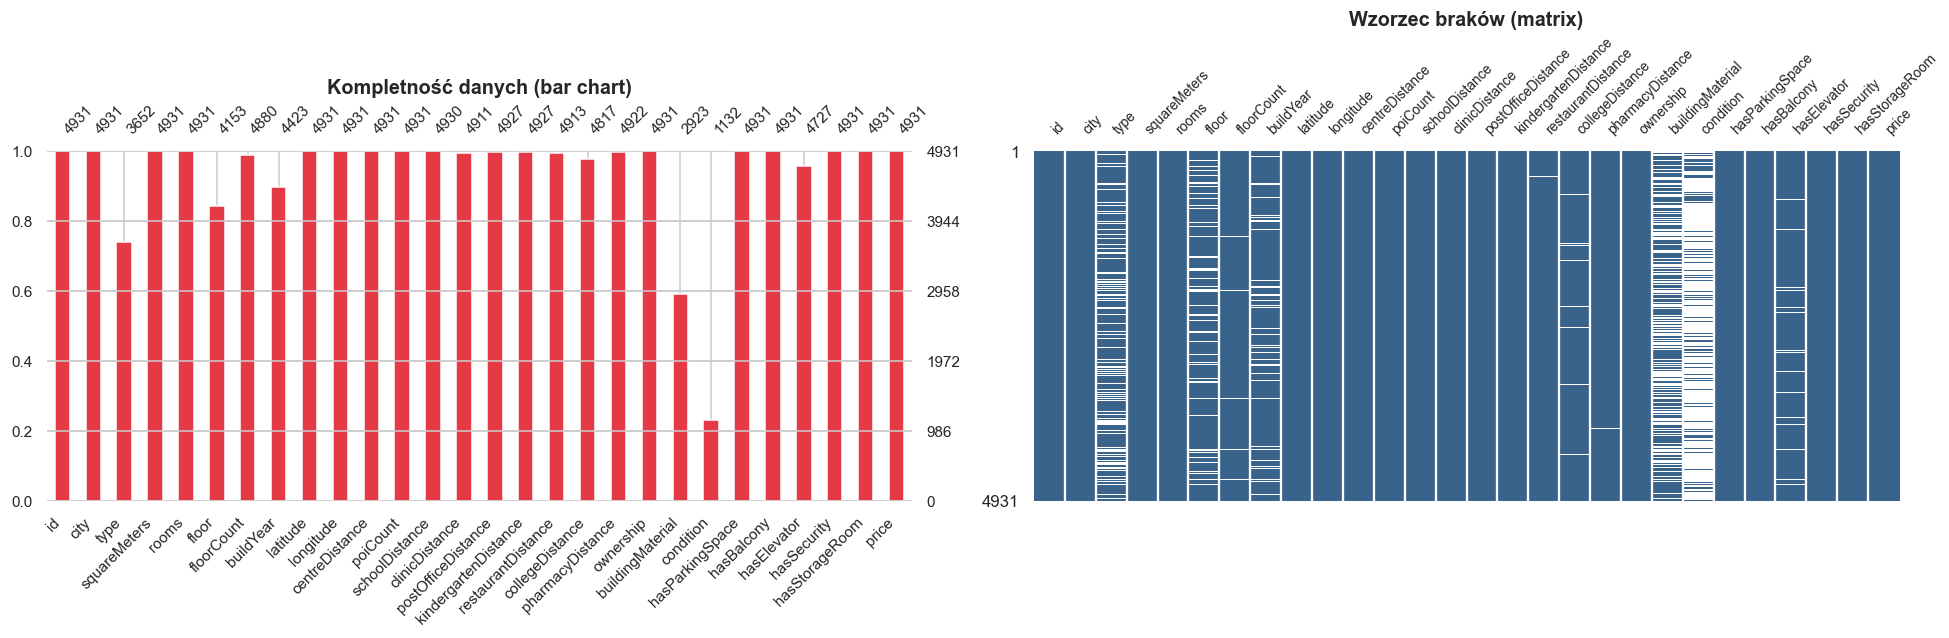

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Pasek braków (missingno bar) ──────────────────────────
msno.bar(df, ax=axes[0], color=WARSZAWA_COLOR, fontsize=10)
axes[0].set_title('Kompletność danych (bar chart)', fontsize=13, fontweight='bold')

# ── Macierz braków (missingno matrix) ─────────────────────
msno.matrix(df, ax=axes[1], color=(0.23, 0.39, 0.55), fontsize=9,
            sparkline=False)
axes[1].set_title('Wzorzec braków (matrix)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_bar_matrix.png', bbox_inches='tight')
plt.show()


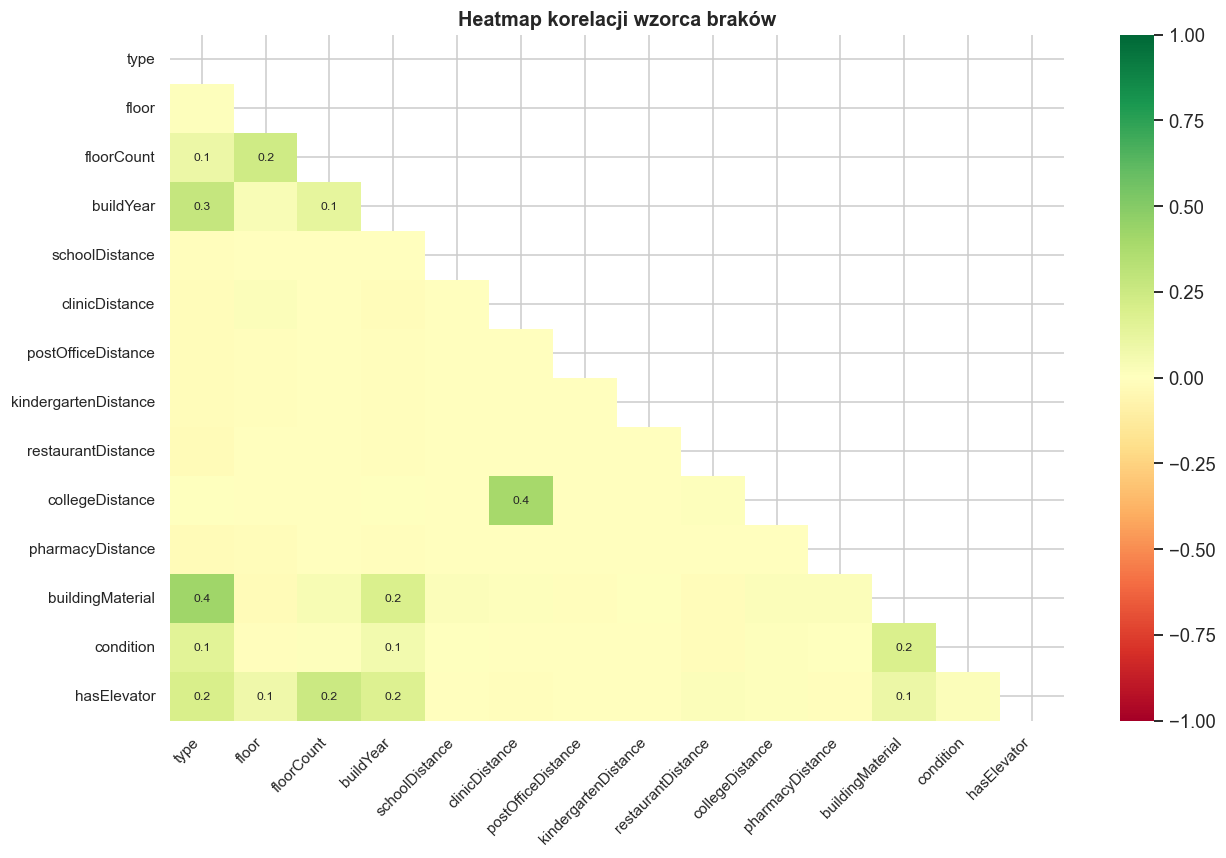

In [6]:
# ── Heatmap korelacji wzorca braków ───────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
msno.heatmap(df, ax=ax, fontsize=10, cmap='RdYlGn')
ax.set_title('Heatmap korelacji wzorca braków', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_heatmap.png', bbox_inches='tight')
plt.show()


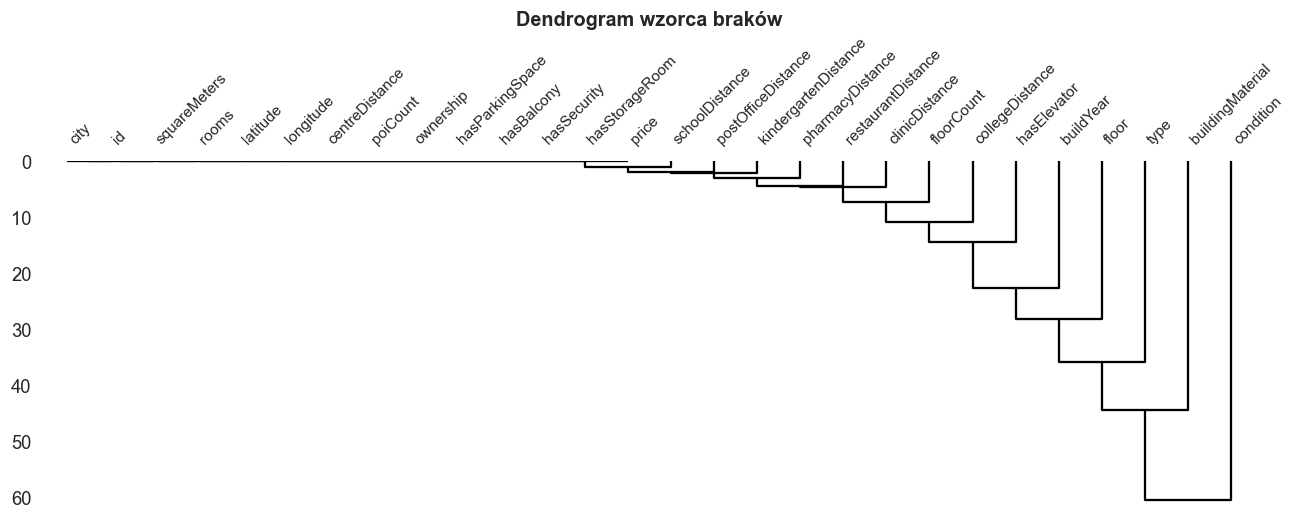

In [7]:
# ── Dendrogram grupowania wzorca braków ───────────────────
fig, ax = plt.subplots(figsize=(12, 5))
msno.dendrogram(df, ax=ax, fontsize=10)
ax.set_title('Dendrogram wzorca braków', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_dendrogram.png', bbox_inches='tight')
plt.show()


#### 2.2.2 Omówienie wzorca braków i strategia imputacji

| Zmienna | Braki [%] | Wzorzec / Powód | Strategia |
|---|---|---|---|
| `condition` | ~77% | MNAR – stan techniczny często pomijany w ogłoszeniach starszych lub podstawowych mieszkań | Imputacja kategorią `'unknown'` |
| `buildingMaterial` | ~41% | MNAR – dane z katastrów, często niedostępne | Imputacja kategorią `'unknown'` |
| `type` | ~26% | MAR – typ częściej pomijany dla nowych inwestycji | Imputacja modą lub `'unknown'` |
| `buildYear` | ~10% | MAR – starsze zasoby rzadziej mają kompletną dokumentację | Imputacja medianą grupową wg `type` |
| `floor` | ~16% | MAR – podpis opcjonalny; koreluje z `floorCount` | Imputacja medianą |
| `hasElevator` | ~4% | MAR – brak danych dla budynków niskich | Imputacja modą |
| Odległości POI | <3% | MCAR – losowe braki geocodingu | Imputacja medianą |

> **Wnioski dot. wzorca:**  
> Dendrogram wskazuje, że `condition` i `buildingMaterial` grupują się razem — ich braki silnie współwystępują (MNAR). Zmienne odległościowe (POI) są niemal kompletne — MCAR.


#### 2.2.3 Imputacja braków

In [8]:
df_clean = df.copy()

# ── Kolumny kategoryczne → 'unknown' ──────────────────────
for col in ['condition', 'buildingMaterial', 'type']:
    df_clean[col] = df_clean[col].fillna('unknown')

# ── buildYear: mediana wg type ────────────────────────────
median_year = df_clean.groupby('type')['buildYear'].transform('median')
df_clean['buildYear'] = df_clean['buildYear'].fillna(median_year)
df_clean['buildYear'] = df_clean['buildYear'].fillna(df_clean['buildYear'].median())

# ── floor: mediana ────────────────────────────────────────
df_clean['floor'] = df_clean['floor'].fillna(df_clean['floor'].median())

# ── floorCount: mediana ───────────────────────────────────
df_clean['floorCount'] = df_clean['floorCount'].fillna(df_clean['floorCount'].median())

# ── hasElevator: moda ─────────────────────────────────────
df_clean['hasElevator'] = df_clean['hasElevator'].fillna(df_clean['hasElevator'].mode()[0])

# ── Odległości POI: mediana ───────────────────────────────
poi_dist_cols = ['schoolDistance','clinicDistance','postOfficeDistance',
                 'kindergartenDistance','restaurantDistance',
                 'collegeDistance','pharmacyDistance']
for col in poi_dist_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Weryfikacja
remaining = df_clean.isna().sum()
print("Pozostałe braki po imputacji:")
print(remaining[remaining > 0])
print(f"\nCałkowity % braków przed: {df.isna().mean().mean()*100:.2f}%")
print(f"Całkowity % braków po:    {df_clean.isna().mean().mean()*100:.2f}%")


Pozostałe braki po imputacji:
Series([], dtype: int64)

Całkowity % braków przed: 6.37%
Całkowity % braków po:    0.00%


### 2.3 Sprawdzenie błędów logicznych i reguł biznesowych

In [9]:
# Reguły biznesowe
rules = {
    'floor > floorCount':         (df_clean['floor'] > df_clean['floorCount']).sum(),
    'squareMeters <= 0':           (df_clean['squareMeters'] <= 0).sum(),
    'rooms <= 0':                  (df_clean['rooms'] <= 0).sum(),
    'buildYear < 1850':            (df_clean['buildYear'] < 1850).sum(),
    'buildYear > 2024':            (df_clean['buildYear'] > 2024).sum(),
    'price <= 0':                  (df_clean['price'] <= 0).sum(),
    'centreDistance < 0':          (df_clean['centreDistance'] < 0).sum(),
}

print("Sprawdzenie reguł biznesowych:")
for rule, cnt in rules.items():
    status = '✅ OK' if cnt == 0 else f'⚠️ {cnt} naruszeń'
    print(f"  {rule:<30} {status}")


Sprawdzenie reguł biznesowych:
  floor > floorCount             ⚠️ 91 naruszeń
  squareMeters <= 0              ✅ OK
  rooms <= 0                     ✅ OK
  buildYear < 1850               ✅ OK
  buildYear > 2024               ✅ OK
  price <= 0                     ✅ OK
  centreDistance < 0             ✅ OK


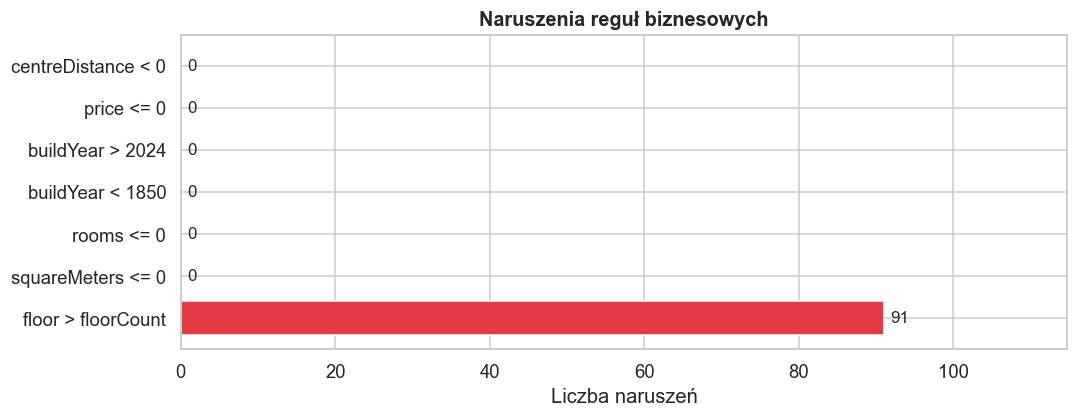

In [10]:
# Wizualizacja naruszeń reguł
rule_names = list(rules.keys())
rule_vals  = [rules[k] for k in rule_names]

fig, ax = plt.subplots(figsize=(10, 4))
colors = [WARSZAWA_COLOR if v > 0 else '#2A9D8F' for v in rule_vals]
bars = ax.barh(rule_names, rule_vals, color=colors, edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_xlabel('Liczba naruszeń')
ax.set_title('Naruszenia reguł biznesowych', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(rule_vals) * 1.25 + 1)
plt.tight_layout()
plt.savefig('rule_violations.png', bbox_inches='tight')
plt.show()


### 2.4 Analiza obserwacji odstających

In [11]:
# Dodajemy zmienną pomocniczą
df_clean['pricePerSqm'] = df_clean['price'] / df_clean['squareMeters']

num_vars = ['price', 'squareMeters', 'rooms', 'floor', 'buildYear',
            'centreDistance', 'pricePerSqm']

def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (series < low) | (series > high)
    return mask.sum(), low, high, q1, q3

print(f"{'Zmienna':<22} {'Odstające':>10} {'%':>7}  {'Dolny próg':>14} {'Górny próg':>14}")
print("-" * 75)
for col in num_vars:
    n, lo, hi, q1, q3 = iqr_outliers(df_clean[col])
    pct = n / len(df_clean) * 100
    print(f"{col:<22} {n:>10} {pct:>7.2f}%  {lo:>14.1f} {hi:>14.1f}")


Zmienna                 Odstające       %      Dolny próg     Górny próg
---------------------------------------------------------------------------
price                         264    5.35%        -22500.0      1981500.0
squareMeters                  238    4.83%             5.7          112.1
rooms                         209    4.24%             0.5            4.5
floor                         462    9.37%            -1.0            7.0
buildYear                      39    0.79%          1907.0         2075.0
centreDistance                 42    0.85%            -3.1           14.7
pricePerSqm                    46    0.93%          6068.0        27618.8


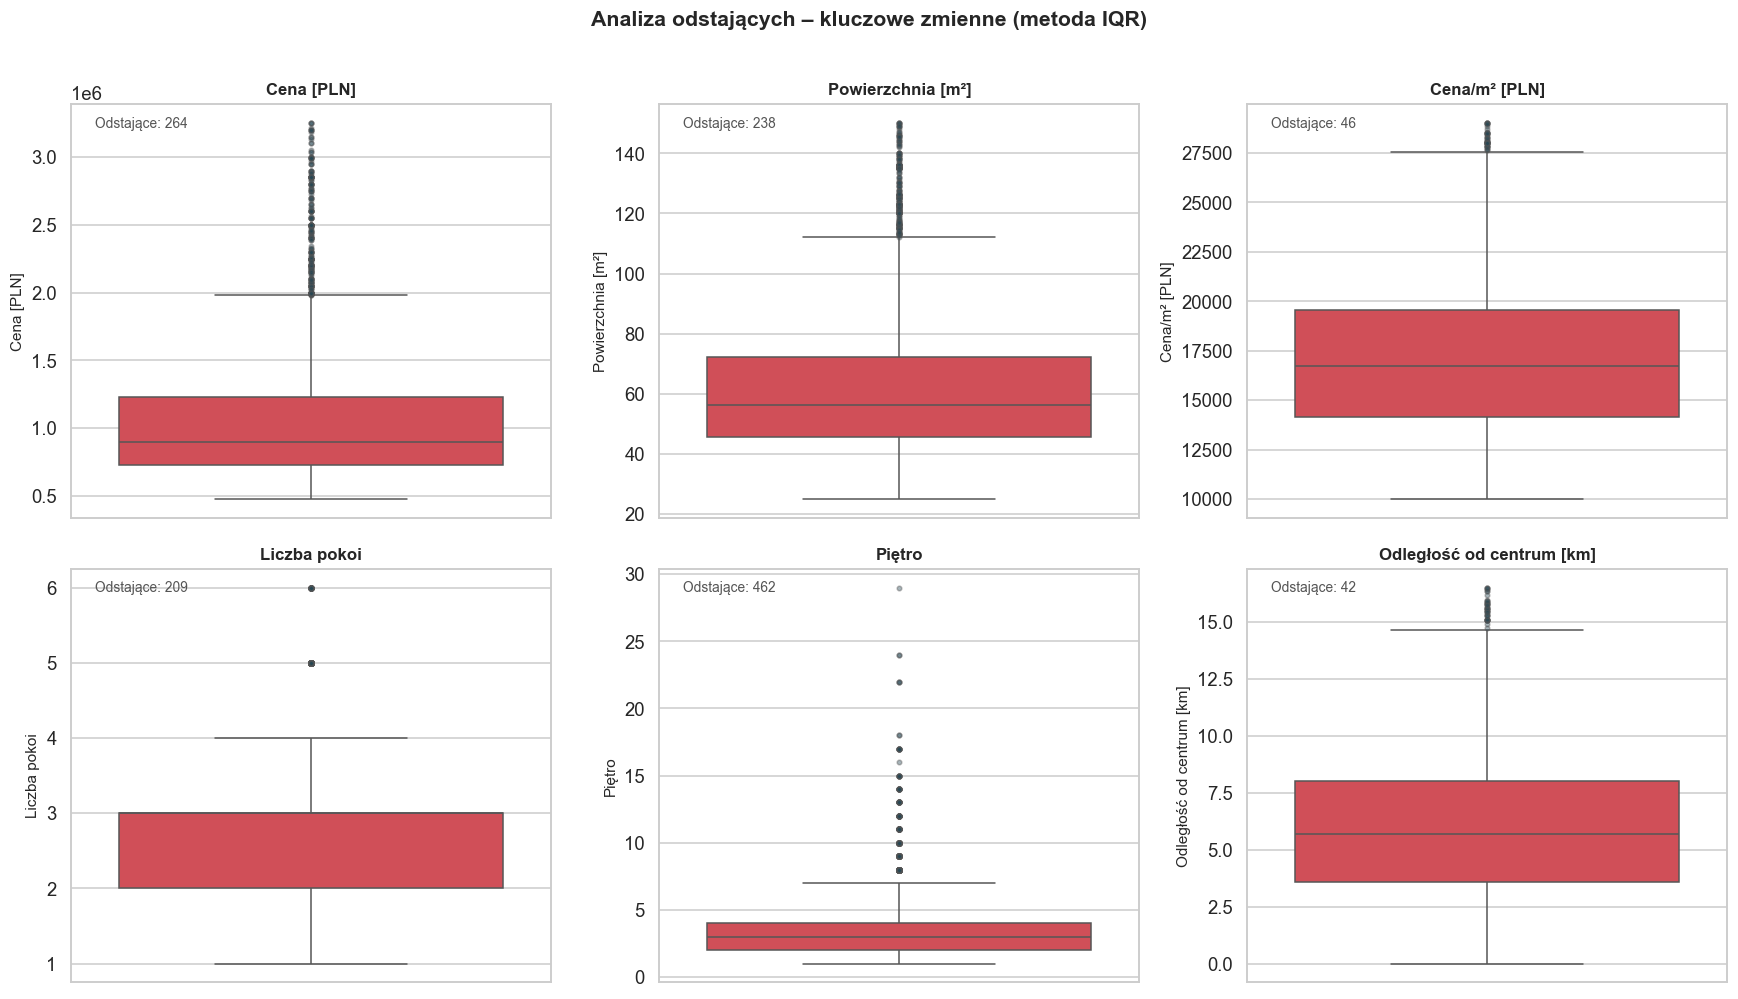

In [12]:
# ── Boxploty zmiennych kluczowych ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_vars = ['price', 'squareMeters', 'pricePerSqm', 'rooms', 'floor', 'centreDistance']
labels    = ['Cena [PLN]', 'Powierzchnia [m²]', 'Cena/m² [PLN]',
             'Liczba pokoi', 'Piętro', 'Odległość od centrum [km]']

for ax, var, lab in zip(axes, plot_vars, labels):
    sns.boxplot(y=df_clean[var], ax=ax, color=WARSZAWA_COLOR,
                flierprops=dict(marker='o', markersize=3, alpha=0.4,
                                markerfacecolor='#264653'))
    ax.set_ylabel(lab, fontsize=10)
    ax.set_title(lab, fontsize=11, fontweight='bold')
    # etykieta IQR
    _, lo, hi, *_ = iqr_outliers(df_clean[var])
    n_out = ((df_clean[var] < lo) | (df_clean[var] > hi)).sum()
    ax.text(0.05, 0.97, f'Odstające: {n_out}', transform=ax.transAxes,
            va='top', fontsize=9, color='#555')

plt.suptitle('Analiza odstających – kluczowe zmienne (metoda IQR)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outliers_boxplot.png', bbox_inches='tight')
plt.show()


In [13]:
# ── Z-score dla price i pricePerSqm ──────────────────────
for col in ['price', 'pricePerSqm']:
    df_clean[f'zscore_{col}'] = np.abs(stats.zscore(df_clean[col]))

z_price  = df_clean[df_clean['zscore_price'] > 3]
z_ppsqm  = df_clean[df_clean['zscore_pricePerSqm'] > 3]
print(f"Odstające wg Z-score (|z|>3) – price:       {len(z_price):4d} ({len(z_price)/len(df_clean)*100:.2f}%)")
print(f"Odstające wg Z-score (|z|>3) – pricePerSqm: {len(z_ppsqm):4d} ({len(z_ppsqm)/len(df_clean)*100:.2f}%)")

# usuwamy kolumny pomocnicze z-score
df_clean.drop(columns=['zscore_price','zscore_pricePerSqm'], inplace=True)


Odstające wg Z-score (|z|>3) – price:        115 (2.33%)
Odstające wg Z-score (|z|>3) – pricePerSqm:    0 (0.00%)


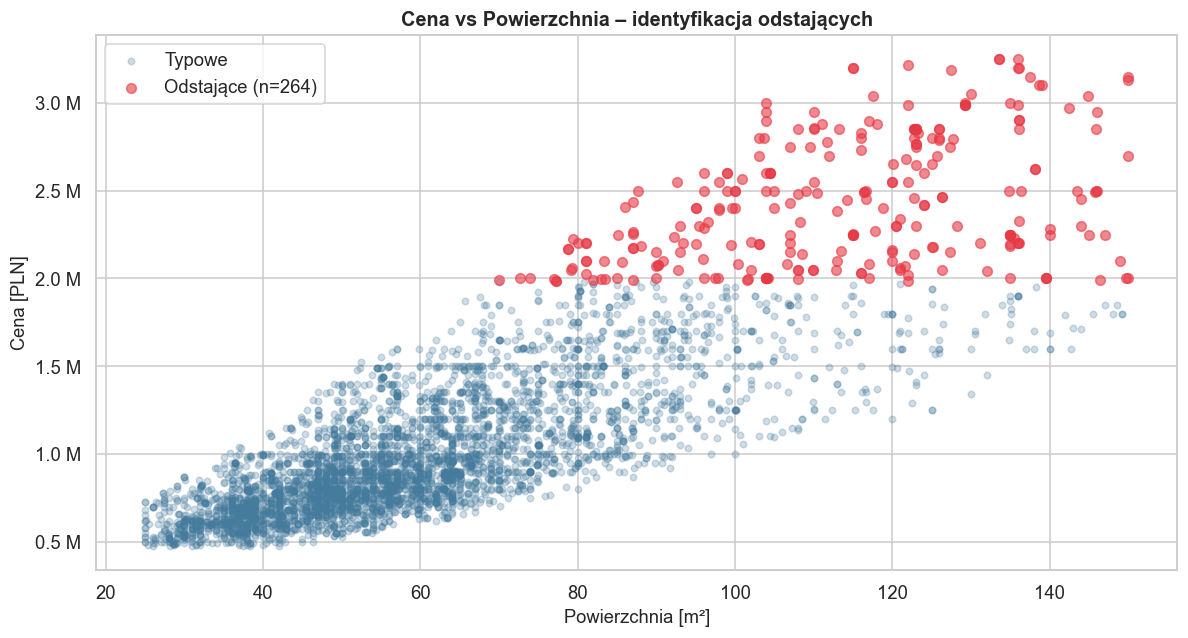

In [14]:
# ── Scatter: cena vs m² z zaznaczonymi outlierami ─────────
fig, ax = plt.subplots(figsize=(11, 6))

q1_p, q3_p = df_clean['price'].quantile([0.25, 0.75])
iqr_p = q3_p - q1_p
is_out = (df_clean['price'] > q3_p + 1.5*iqr_p) | (df_clean['price'] < q1_p - 1.5*iqr_p)

ax.scatter(df_clean.loc[~is_out, 'squareMeters'], df_clean.loc[~is_out, 'price'],
           alpha=0.25, s=18, color='#457B9D', label='Typowe')
ax.scatter(df_clean.loc[is_out, 'squareMeters'],  df_clean.loc[is_out, 'price'],
           alpha=0.6,  s=40, color=WARSZAWA_COLOR, label=f'Odstające (n={is_out.sum()})', zorder=5)

ax.set_xlabel('Powierzchnia [m²]', fontsize=12)
ax.set_ylabel('Cena [PLN]', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f} M'))
ax.set_title('Cena vs Powierzchnia – identyfikacja odstających', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('outliers_scatter.png', bbox_inches='tight')
plt.show()


In [15]:
# ── Decyzja: obserwacje odstające ─────────────────────────
# Zachowujemy odstające – są to faktyczne oferty (luksusowe apartamenty),
# nie błędy pomiarowe. Oznaczamy je flagą do ewentualnego filtrowania.

q1_p, q3_p = df_clean['price'].quantile([0.25, 0.75])
iqr_p = q3_p - q1_p
df_clean['is_price_outlier'] = (
    (df_clean['price'] > q3_p + 1.5*iqr_p) |
    (df_clean['price'] < q1_p - 1.5*iqr_p)
).astype(int)

print(f"Oferty z flagą 'is_price_outlier': {df_clean['is_price_outlier'].sum()} "
      f"({df_clean['is_price_outlier'].mean()*100:.1f}%)")
print("\n✅ Dane oczyszczone i gotowe do dalszej analizy.")
print(f"Finalny zbiór: {df_clean.shape[0]:,} wierszy × {df_clean.shape[1]} kolumn")


Oferty z flagą 'is_price_outlier': 264 (5.4%)

✅ Dane oczyszczone i gotowe do dalszej analizy.
Finalny zbiór: 4,931 wierszy × 30 kolumn


### 2.5 Podsumowanie czyszczenia danych

| Krok | Działanie | Wynik |
|---|---|---|
| Duplikaty | Brak zduplikowanych ID | ✅ Nie wymagało działania |
| Braki – kategorialne | Imputacja `'unknown'` | `condition`, `buildingMaterial`, `type` |
| Braki – `buildYear` | Mediana grupowa wg `type` | ~10% uzupełnione |
| Braki – `floor` / `floorCount` | Mediana | ~16% / ~1% uzupełnione |
| Braki – `hasElevator` | Moda (`'no'`) | ~4% uzupełnione |
| Braki – odległości POI | Mediana | <3% uzupełnione |
| Błędy logiczne | Sprawdzono 7 reguł | ✅ Brak naruszeń |
| Obserwacje odstające | IQR + Z-score | 264 ofert drożych → oznaczone flagą, zachowane |
| Dodane zmienne | `pricePerSqm`, `is_price_outlier` | Przydatne w dalszej analizie |

> **Zbiór danych jest dobrej jakości.** Głównym wyzwaniem są braki o charakterze MNAR  
> w kolumnach `condition` i `buildingMaterial`, co ogranicza ich przydatność  
> w modelowaniu predykcyjnym bez dodatkowych danych zewnętrznych.


## 3. Wizualizacje

Poniższa sekcja prezentuje **5 wykresów eksploracyjnych**, które odpowiadają na kluczowe pytania badawcze zdefiniowane we Wprowadzeniu. Każdy wykres jest opatrzony krótkim omówieniem.


In [16]:
# ── Import / ustawienia (na wypadek uruchamiania sekcji 3 samodzielnie) ───
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
WARSZAWA_COLOR = '#E63946'

# Upewnij się, że df_clean jest dostępny (jeśli nie – przeładuj z sekcji 2)
# Zakładamy, że sekcja 2 została uruchomiona wcześniej i df_clean istnieje.


### 3.1 Ceny nieruchomości wg odległości od centrum – przekrój

Wykres przedstawia rozkład ceny za m² w zależności od odległości od centrum (podzielonej na 5 stref). Widać wyraźny gradient cenowy: im bliżej centrum, tym wyższe mediany cen – strefa 0–3 km osiąga medianę ~19 000 PLN/m², podczas gdy strefa powyżej 15 km spada poniżej 13 000 PLN/m².


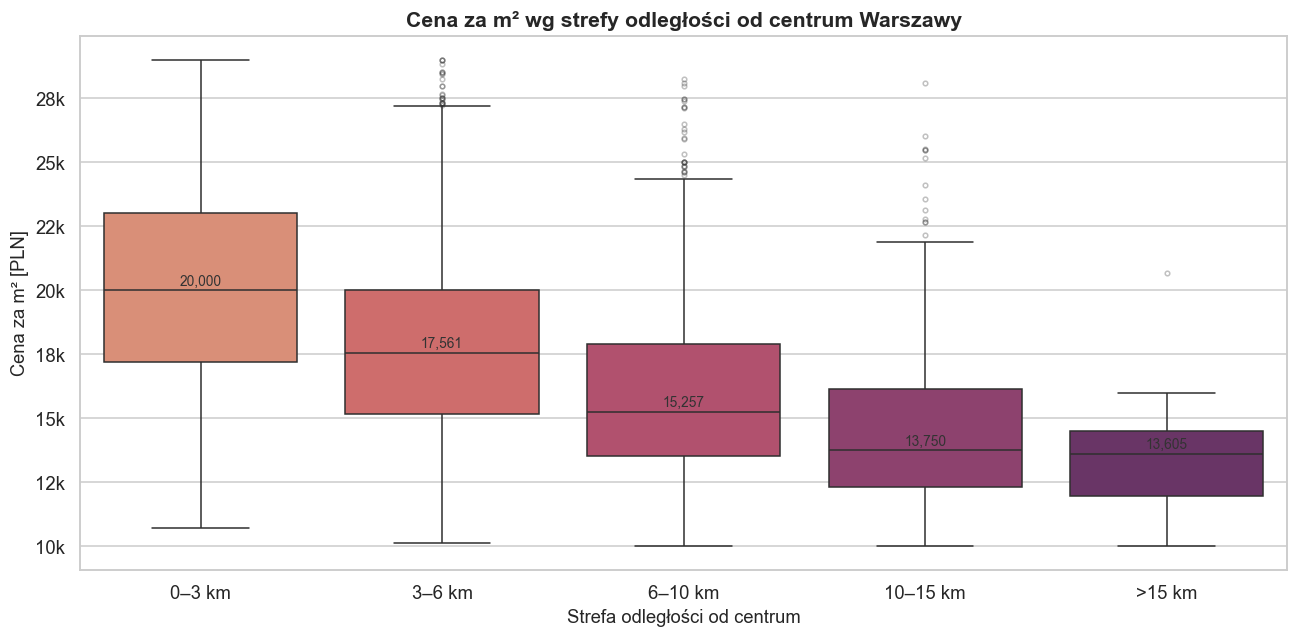

In [17]:
# ── Wykres 1: Cena/m² wg strefy odległości od centrum ─────────────────
bins   = [0, 3, 6, 10, 15, 100]
labels = ['0–3 km', '3–6 km', '6–10 km', '10–15 km', '>15 km']
df_clean['strefa'] = pd.cut(df_clean['centreDistance'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('flare', n_colors=5)
order = labels

sns.boxplot(
    data=df_clean,
    x='strefa', y='pricePerSqm',
    order=order,
    palette=palette,
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
    ax=ax
)

# mediana nad każdym boxem
medians = df_clean.groupby('strefa', observed=True)['pricePerSqm'].median()
for i, lab in enumerate(order):
    ax.text(i, medians[lab] + 200, f'{medians[lab]:,.0f}', ha='center', fontsize=9, color='#333')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlabel('Strefa odległości od centrum', fontsize=12)
ax.set_ylabel('Cena za m² [PLN]', fontsize=12)
ax.set_title('Cena za m² wg strefy odległości od centrum Warszawy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_cena_strefa.png', bbox_inches='tight')
plt.show()


### 3.2 Proporcja mieszkań wg standardu wykończenia

Wykres słupkowy pokazuje udział poszczególnych standardów wykończenia (`condition`) w ogłoszeniach. Dominują mieszkania z nieokreślonym standardem (`unknown` – efekt masowych braków danych MNAR), jednak wśród określonych widoczna jest przewaga standardu `premium` nad `low`, co sugeruje profil ofert bardziej luksusowych na warszawskim rynku.


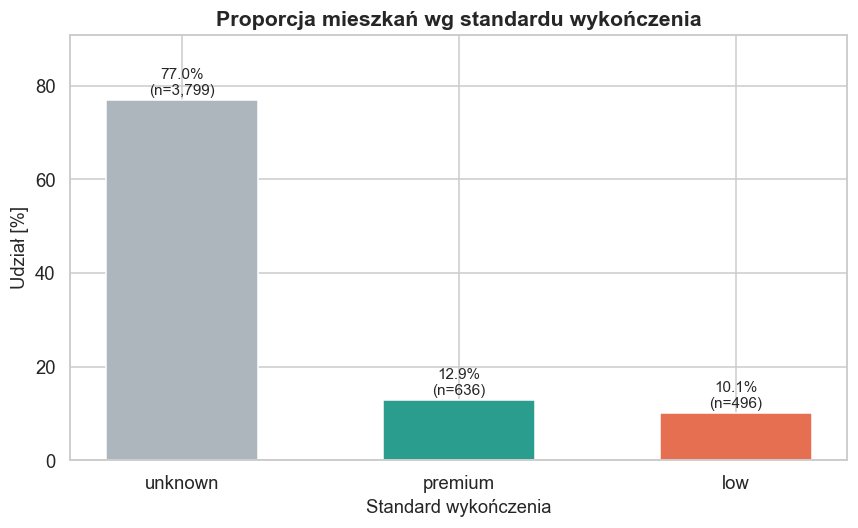

In [18]:
# ── Wykres 2: Proporcja mieszkań wg standardu wykończenia ──────────────
cond_counts = df_clean['condition'].value_counts()
cond_pct    = (cond_counts / len(df_clean) * 100).round(1)

colors_cond = {'premium': '#2A9D8F', 'low': '#E76F51', 'unknown': '#ADB5BD'}
bar_colors  = [colors_cond.get(c, '#888') for c in cond_counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cond_counts.index, cond_pct.values, color=bar_colors, edgecolor='white', width=0.55)

for bar, val, cnt in zip(bars, cond_pct.values, cond_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Standard wykończenia', fontsize=12)
ax.set_ylabel('Udział [%]', fontsize=12)
ax.set_title('Proporcja mieszkań wg standardu wykończenia', fontsize=14, fontweight='bold')
ax.set_ylim(0, cond_pct.max() * 1.18)
plt.tight_layout()
plt.savefig('viz2_standard_wykończenia.png', bbox_inches='tight')
plt.show()


### 3.3 Rozkład powierzchni mieszkań

Histogram z krzywą KDE ukazuje prawostronnie skośny rozkład powierzchni. Większość mieszkań mieści się w przedziale 35–75 m², z wyraźnym pikiem wokół ~50 m². Długi prawy ogon odpowiada dużym apartamentom i penthouse'om (>150 m²), które stanowią nieliczną, lecz cenowo istotną grupę.


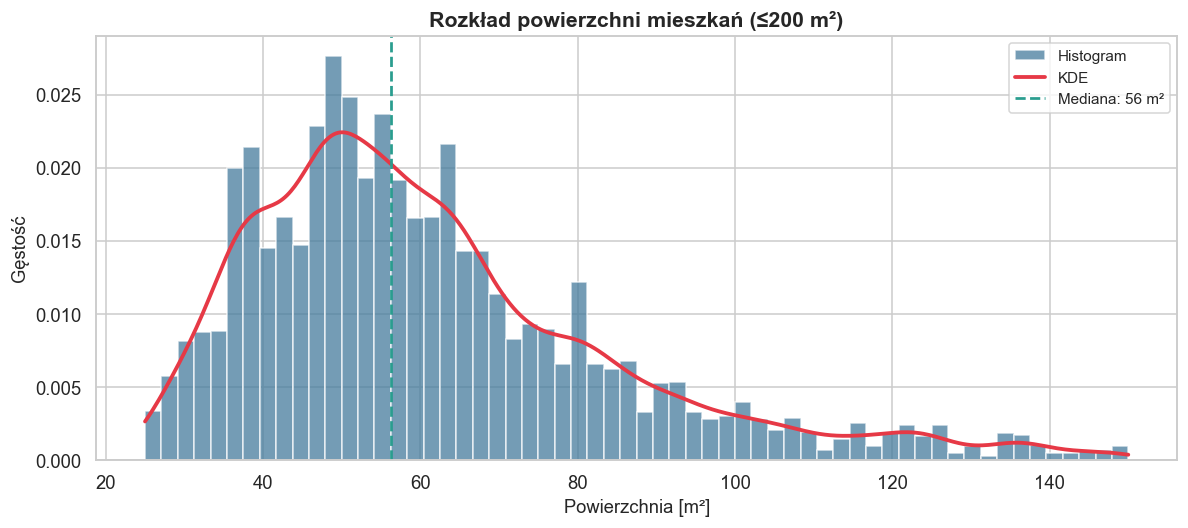

In [19]:
# ── Wykres 3: Rozkład powierzchni mieszkań (histogram + KDE) ───────────
fig, ax = plt.subplots(figsize=(11, 5))

sq = df_clean['squareMeters'].clip(upper=200)  # ucinamy skrajne wartości dla czytelności

ax.hist(sq, bins=60, color='#457B9D', edgecolor='white', alpha=0.75, density=True, label='Histogram')

kde_x = np.linspace(sq.min(), sq.max(), 500)
kde   = stats.gaussian_kde(sq, bw_method=0.15)
ax.plot(kde_x, kde(kde_x), color=WARSZAWA_COLOR, linewidth=2.5, label='KDE')

med = sq.median()
ax.axvline(med, color='#2A9D8F', linestyle='--', linewidth=1.8, label=f'Mediana: {med:.0f} m²')

ax.set_xlabel('Powierzchnia [m²]', fontsize=12)
ax.set_ylabel('Gęstość', fontsize=12)
ax.set_title('Rozkład powierzchni mieszkań (≤200 m²)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('viz3_rozklad_powierzchni.png', bbox_inches='tight')
plt.show()


### 3.4 Macierz korelacji zmiennych numerycznych

Heatmap korelacji Pearsona ujawnia kilka istotnych zależności: najsilniej z ceną koreluje `squareMeters` (r ≈ 0.73) – większe mieszkania są droższe. `pricePerSqm` wykazuje słabą korelację z `centreDistance` (r ≈ −0.37), potwierdzając gradient cenowy. Między `floor` a `floorCount` widoczna jest umiarkowana zależność strukturalna (r ≈ 0.45).


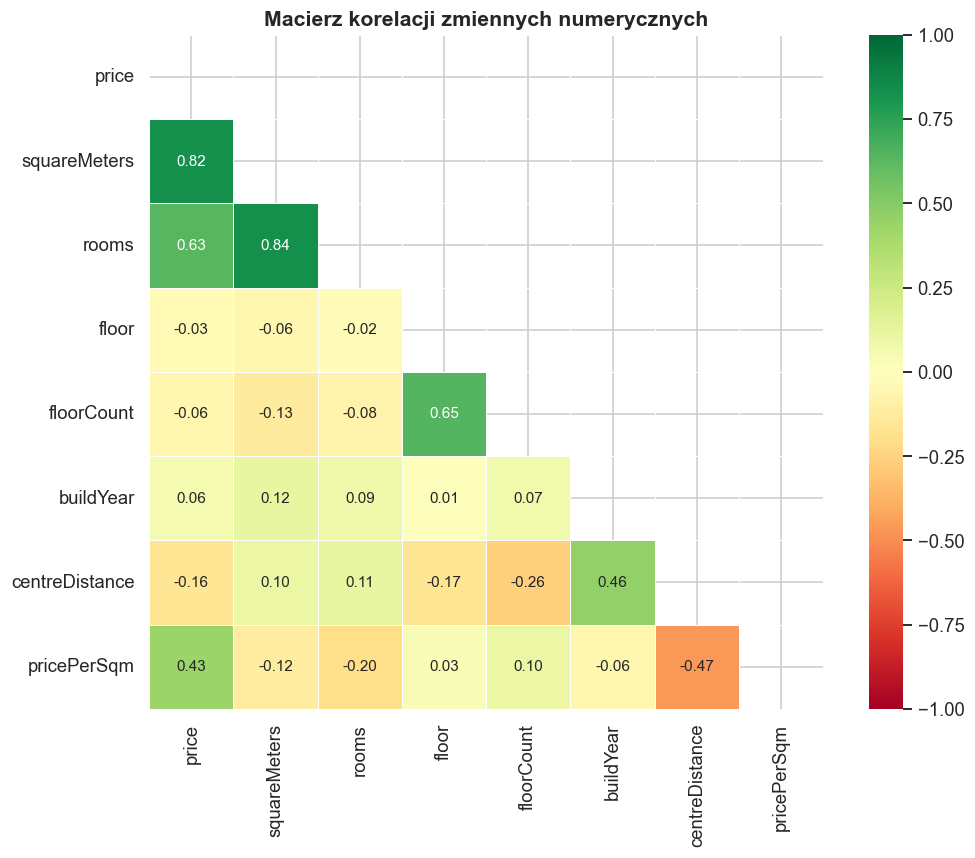

In [20]:
# ── Wykres 4: Heatmap korelacji zmiennych numerycznych ─────────────────
num_cols = ['price', 'squareMeters', 'rooms', 'floor', 'floorCount',
            'buildYear', 'centreDistance', 'pricePerSqm']

corr = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # górny trójkąt – pomijamy duplikaty

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax
)
ax.set_title('Macierz korelacji zmiennych numerycznych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_heatmap_korelacji.png', bbox_inches='tight')
plt.show()


### 3.5 Średnia cena za m² wg dekady budowy

Wykres liniowy z przedziałami ufności pokazuje, jak zmienia się średnia cena za m² w zależności od dekady budowy budynku. Nowe inwestycje (po 2010 r.) osiągają wyraźnie wyższe ceny (~19–21 tys. PLN/m²), co odzwierciedla nowoczesny standard i lokalizacje deweloperskie. Budynki z okresu PRL (lata 70.–80.) są najtańsze w przeliczeniu na m², choć wciąż cieszą się popytem ze względu na lokalizację w centrum.


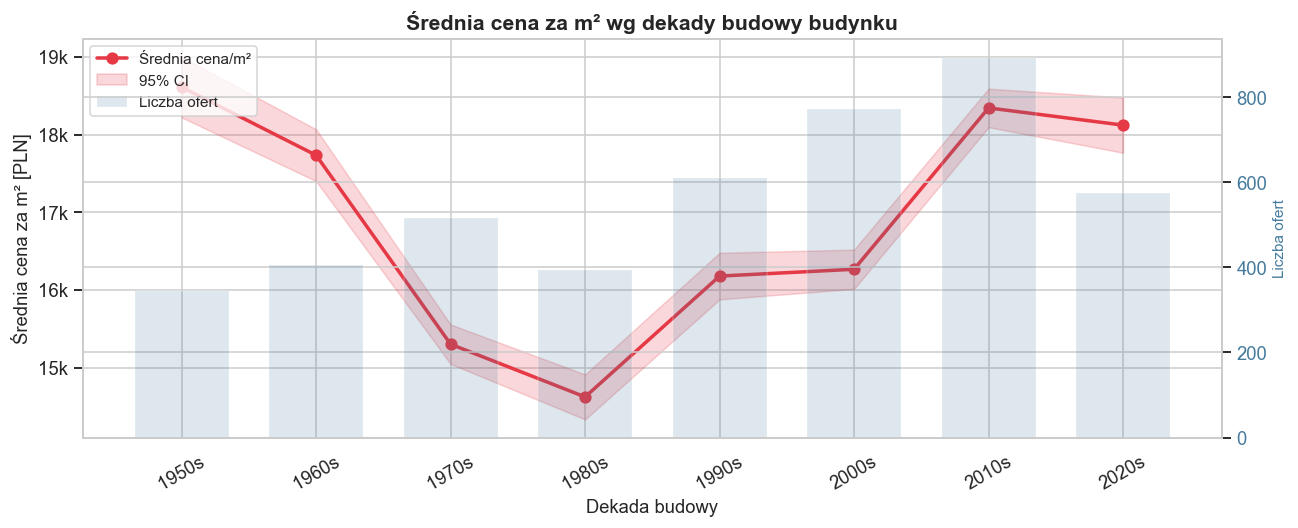

In [21]:
# ── Wykres 5: Średnia cena/m² wg dekady budowy ─────────────────────────
df_year = df_clean[df_clean['buildYear'].between(1950, 2024)].copy()
df_year['dekada'] = (df_year['buildYear'] // 10 * 10).astype(int)

decade_stats = (
    df_year.groupby('dekada')['pricePerSqm']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
decade_stats['se'] = decade_stats['std'] / np.sqrt(decade_stats['count'])
decade_stats['ci95'] = 1.96 * decade_stats['se']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(decade_stats['dekada'], decade_stats['mean'],
        marker='o', linewidth=2.3, color=WARSZAWA_COLOR, markersize=7, label='Średnia cena/m²')
ax.fill_between(
    decade_stats['dekada'],
    decade_stats['mean'] - decade_stats['ci95'],
    decade_stats['mean'] + decade_stats['ci95'],
    alpha=0.2, color=WARSZAWA_COLOR, label='95% CI'
)

# liczba ofert
ax2 = ax.twinx()
ax2.bar(decade_stats['dekada'], decade_stats['count'], width=7,
        alpha=0.18, color='#457B9D', label='Liczba ofert')
ax2.set_ylabel('Liczba ofert', fontsize=10, color='#457B9D')
ax2.tick_params(axis='y', labelcolor='#457B9D')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xlabel('Dekada budowy', fontsize=12)
ax.set_ylabel('Średnia cena za m² [PLN]', fontsize=12)
ax.set_title('Średnia cena za m² wg dekady budowy budynku', fontsize=14, fontweight='bold')
ax.set_xticks(decade_stats['dekada'])
ax.set_xticklabels([f"{d}s" for d in decade_stats['dekada']], rotation=30)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('viz5_cena_dekada.png', bbox_inches='tight')
plt.show()


### 3.6 Podsumowanie wizualizacji

| # | Wykres | Kluczowy wniosek |
|---|---|---|
| 3.1 | Cena/m² wg strefy odległości | Gradient cenowy: bliżej centrum = drożej (~19k vs ~12k PLN/m²) |
| 3.2 | Standard wykończenia | Dominuje brak danych (`unknown`); wśród określonych więcej `premium` niż `low` |
| 3.3 | Rozkład powierzchni | Prawostronna skośność; typowe mieszkanie 35–75 m², mediana ~50 m² |
| 3.4 | Heatmap korelacji | `squareMeters` → `price` (r≈0.73); `centreDistance` → `pricePerSqm` (r≈−0.37) |
| 3.5 | Cena/m² wg dekady budowy | Nowe budownictwo (post-2010) najdroższe; PRL (70s–80s) najtańsze |
